In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
data=pd.read_csv('titanic_toy.csv')
data.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
data.isna().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [7]:
X=data.drop(columns=['Survived'])
y=data['Survived']

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [10]:
X_train.isna().sum()

Age       140
Fare       36
Family      0
dtype: int64

In [15]:
age_mean=X_train['Age'].mean()
age_median=X_train['Age'].median()

fare_mean=X_train['Fare'].mean()
fare_median=X_train['Fare'].median()


In [16]:
age_mean,age_median

(np.float64(29.498846153846156), np.float64(28.0))

In [17]:
X_train['age_mean']=X_train['Age'].fillna(age_mean)
X_train['age_median']=X_train['Age'].fillna(age_median)

X_train['fare_mean']=X_train['Fare'].fillna(fare_mean)
X_train['fare_median']=X_train['Fare'].fillna(fare_median)

In [18]:
X_train.sample(5)

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
354,NaN,7.225,0,29.498846,28.0,7.225000,7.225
336,29.0,NaN,1,29.000000,29.0,32.517788,14.400
373,22.0,NaN,0,22.000000,22.0,32.517788,14.400
678,43.0,46.900,7,43.000000,43.0,46.900000,46.900
888,NaN,23.450,3,29.498846,28.0,23.450000,23.450


In [23]:
print("Original Variance ")
print("Age Variance: ",X_train['Age'].var())
print("Fare Variance: ",X_train['Fare'].var())
print()
print("Variance Using Imputation: ")
print("Age Mean Impute Variance: ",X_train['age_mean'].var())
print("Fare Mean Impute Variance: ",X_train['fare_mean'].var())
print("Age Median Impute Variance: ",X_train['age_median'].var())
print("Fare Median Impute Variance: ",X_train['fare_median'].var())

Original Variance 
Age Variance:  210.2517072477435
Fare Variance:  2761.0314349486343

Variance Using Imputation: 
Age Mean Impute Variance:  168.85193366872227
Fare Mean Impute Variance:  2621.232374951235
Age Median Impute Variance:  169.20731007048155
Fare Median Impute Variance:  2637.012481677765


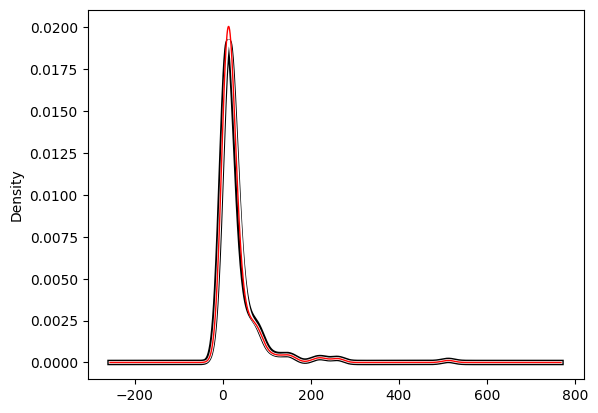

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Fare'].plot(kind='kde',ax=ax,linewidth=4,color='black')

X_train['fare_mean'].plot(kind='kde',ax=ax,linewidth=2,color='white')

X_train['fare_median'].plot(kind='kde',ax=ax,linewidth=1,color='red')
plt.show()

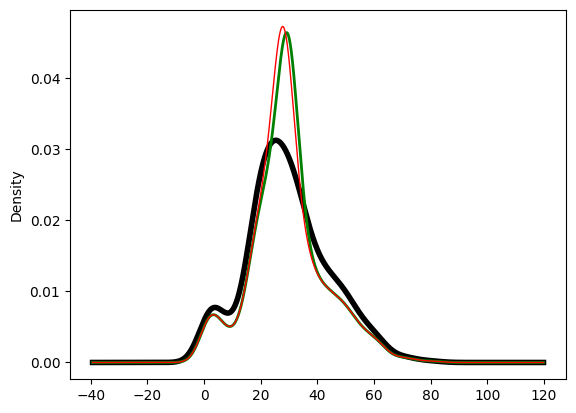

In [31]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind='kde',ax=ax,linewidth=4,color='black')

X_train['age_mean'].plot(kind='kde',ax=ax,linewidth=2,color='green')

X_train['age_median'].plot(kind='kde',ax=ax,linewidth=1,color='red')
plt.show()

In [32]:
X_train.cov()

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,71.193767,70.082085
Fare,75.481375,2761.031435,18.599163,60.224654,63.938058,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-5.616299,-5.587710,17.657433,17.672035
age_mean,210.251707,60.224654,-5.616299,168.851934,168.851934,57.175304,56.282518
age_median,210.251707,63.938058,-5.587710,168.851934,169.207310,60.700688,59.728510
fare_mean,71.193767,2761.031435,17.657433,57.175304,60.700688,2621.232375,2621.232375
fare_median,70.082085,2761.031435,17.672035,56.282518,59.728510,2621.232375,2637.012482


In [33]:
X_train.corr()

,Age,Fare,Family,age_mean,age_median,fare_mean,fare_median
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.088944,0.087232
Fare,0.091482,1.000000,0.207193,0.088151,0.093496,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.256883,-0.255307,0.204981,0.204536
age_mean,1.000000,0.088151,-0.256883,1.000000,0.998949,0.085941,0.084346
age_median,1.000000,0.093496,-0.255307,0.998949,1.000000,0.091145,0.089416
fare_mean,0.088944,1.000000,0.204981,0.085941,0.091145,1.000000,0.997003
fare_median,0.087232,1.000000,0.204536,0.084346,0.089416,0.997003,1.000000


<Axes: >

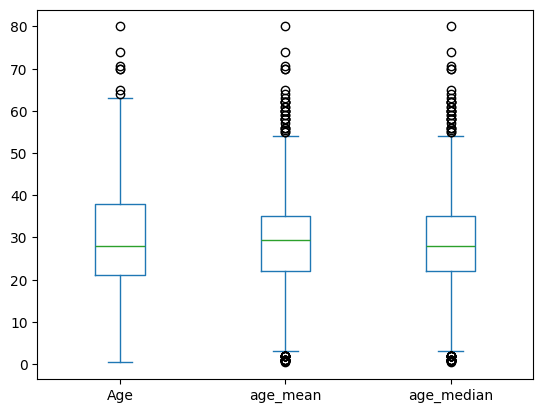

In [34]:
X_train[['Age','age_mean','age_median']].plot(kind='box')

In [41]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [42]:
from sklearn.impute import SimpleImputer

s_mean = SimpleImputer(strategy='mean')
s_median = SimpleImputer(strategy='median')

In [43]:
from sklearn.compose import ColumnTransformer

tr_mean=ColumnTransformer(transformers=[
    ('age and fare mean',s_mean,['Age','Fare'])
],remainder='passthrough')

tr_mean=ColumnTransformer(transformers=[
    ('age and fare median',s_median,['Age','Fare'])
],remainder='passthrough')

In [44]:
X_train_mean=tr_mean.fit_transform(X_train)
X_test_mean=tr_mean.transform(X_test)

X_train_median=tr_mean.fit_transform(X_train)
X_test_median=tr_mean.transform(X_test)

In [ ]:
# fill using arbitory value

In [51]:
X_train['Age_99']=X_train['Age'].fillna(99)
X_train['Age_-1']=X_train['Age'].fillna(-1)

X_train['Fare_99']=X_train['Fare'].fillna(99)
X_train['Fare_-1']=X_train['Fare'].fillna(-1)

In [53]:
X_train.isna().sum()

Age        140
Fare        36
Family       0
Age_99       0
Age_-1       0
Fare_99      0
Fare_-1      0
dtype: int64

In [54]:
print("Original Variance ")
print("Age Variance: ",X_train['Age'].var())
print("Fare Variance: ",X_train['Fare'].var())
print()
print("Variance Using Imputation: ")

print("Age 99 Impute Variance: ",X_train['Age_99'].var())
print("Fare 99 Impute Variance: ",X_train['Fare_99'].var())

print("Age -1 Impute Variance: ",X_train['Age_-1'].var())
print("Fare -1 Impute Variance: ",X_train['Fare_-1'].var())

Original Variance 
Age Variance:  210.2517072477435
Fare Variance:  2761.0314349486343

Variance Using Imputation: 
Age 99 Impute Variance:  932.9665366701432
Fare 99 Impute Variance:  2833.708690936761
Age -1 Impute Variance:  315.9955036260055
Fare -1 Impute Variance:  2675.2394049177024


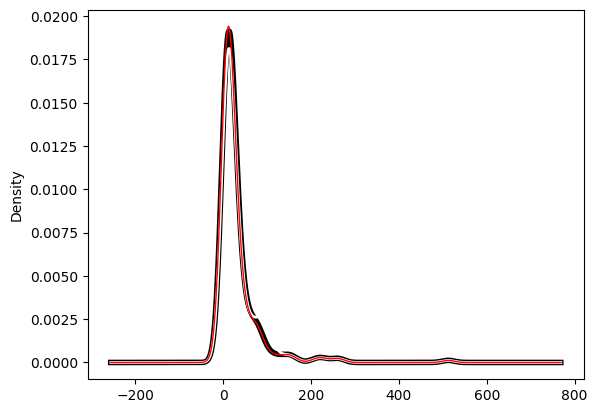

In [55]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Fare'].plot(kind='kde',ax=ax,linewidth=4,color='black')

X_train['Fare_99'].plot(kind='kde',ax=ax,linewidth=2,color='white')

X_train['Fare_-1'].plot(kind='kde',ax=ax,linewidth=1,color='red')
plt.show()

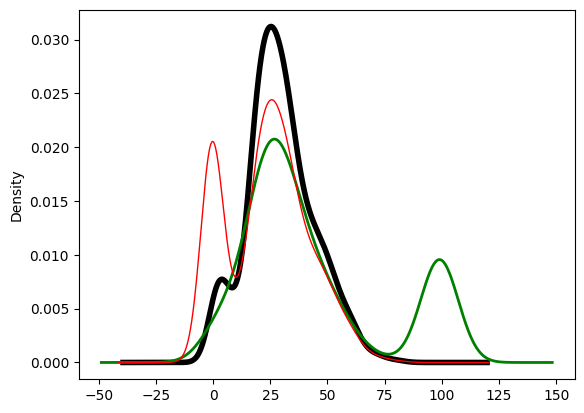

In [56]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind='kde',ax=ax,linewidth=4,color='black')

X_train['Age_99'].plot(kind='kde',ax=ax,linewidth=2,color='green')

X_train['Age_-1'].plot(kind='kde',ax=ax,linewidth=1,color='red')
plt.show()

In [57]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_-1,Fare_99,Fare_-1
Age,210.251707,75.481375,-6.993325,210.251707,210.251707,75.273024,69.137162
Fare,75.481375,2761.031435,18.599163,-111.965046,135.785804,2761.031435,2761.031435
Family,-6.993325,18.599163,2.830892,-6.941982,-5.034556,17.603852,17.684447
Age_99,210.251707,-111.965046,-6.941982,932.966537,-166.460682,-116.528480,-101.137070
Age_-1,210.251707,135.785804,-5.034556,-166.460682,315.995504,138.114503,124.270305
Fare_99,75.273024,2761.031435,17.603852,-116.528480,138.114503,2833.708691,2514.109946
Fare_-1,69.137162,2761.031435,17.684447,-101.137070,124.270305,2514.109946,2675.239405


In [58]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_-1,Fare_99,Fare_-1
Age,1.000000,0.091482,-0.319651,1.000000,1.000000,0.091016,0.085422
Fare,0.091482,1.000000,0.207193,-0.069365,0.145071,1.000000,1.000000
Family,-0.319651,0.207193,1.000000,-0.135079,-0.168329,0.196548,0.203212
Age_99,1.000000,-0.069365,-0.135079,1.000000,-0.306576,-0.071667,-0.064017
Age_-1,1.000000,0.145071,-0.168329,-0.306576,1.000000,0.145956,0.135159
Fare_99,0.091016,1.000000,0.196548,-0.071667,0.145956,1.000000,0.913115
Fare_-1,0.085422,1.000000,0.203212,-0.064017,0.135159,0.913115,1.000000


In [ ]:
# fill using group by
# fill using arbitory value
# fill using random value
# in cat data fill using mode

In [59]:
# categorycal values

In [60]:
df = pd.read_csv('train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [61]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [62]:
df.isna().sum()

FireplaceQu    690
GarageQual      81
SalePrice        0
dtype: int64

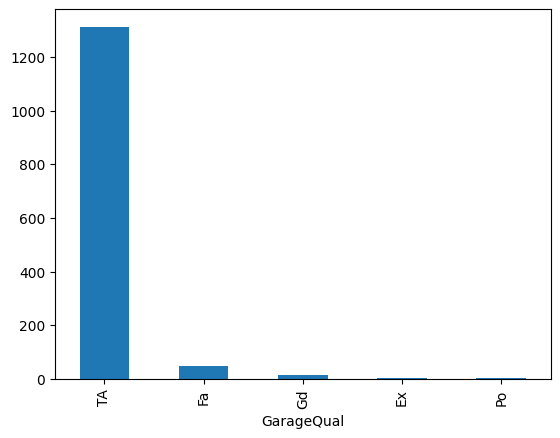

In [64]:
df['GarageQual'].value_counts().plot(kind='bar')
plt.show()

In [65]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

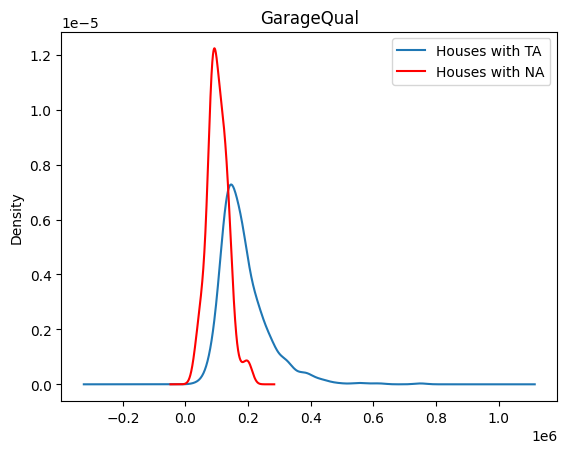

In [67]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax)

df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')
plt.show()

In [68]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [69]:
df['GarageQual'].fillna('TA', inplace=True)

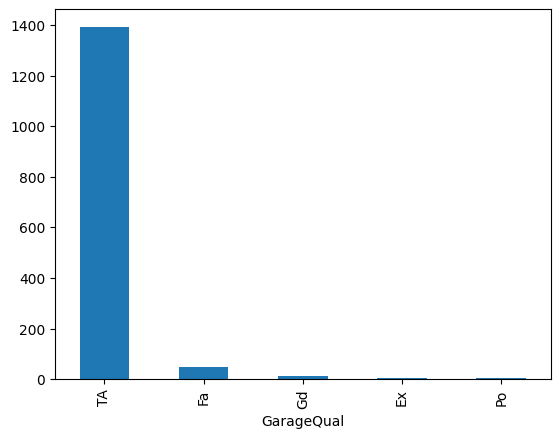

In [71]:
df['GarageQual'].value_counts().plot(kind='bar')
plt.show()

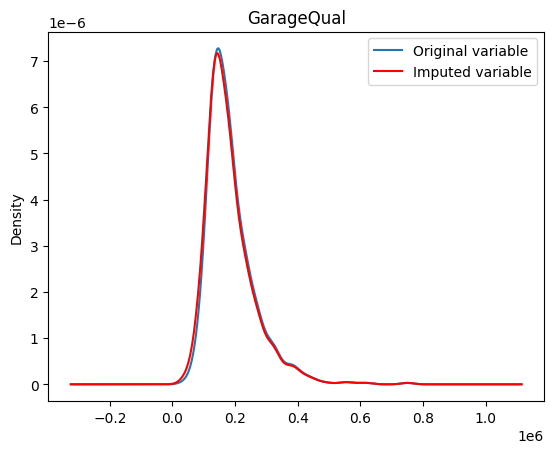

In [73]:
fig = plt.figure()
ax = fig.add_subplot(111)


temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('GarageQual')
plt.show()

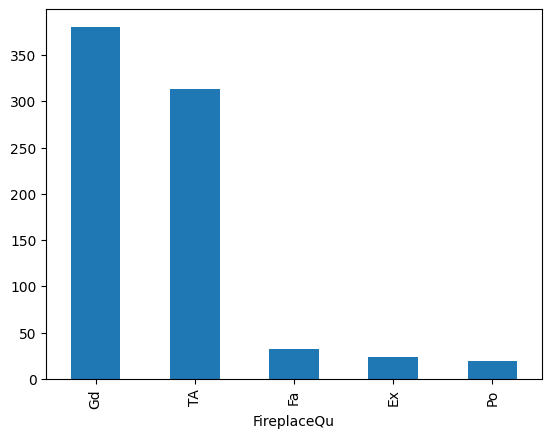

In [75]:
df['FireplaceQu'].value_counts().plot(kind='bar')
plt.show()

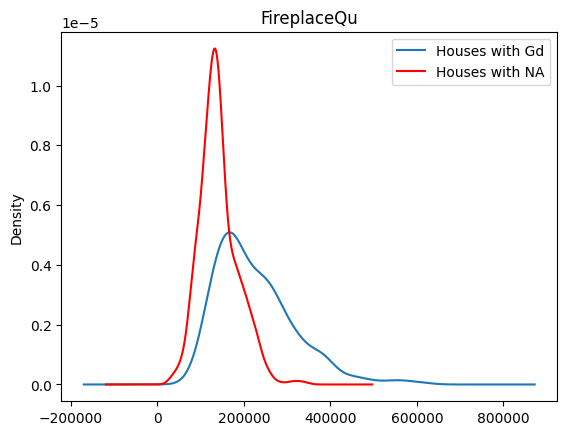

In [76]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax)

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')
plt.show()

In [77]:
temp = df[df['FireplaceQu']=='Gd']['SalePrice']

In [78]:
df['FireplaceQu'].fillna('Gd', inplace=True)

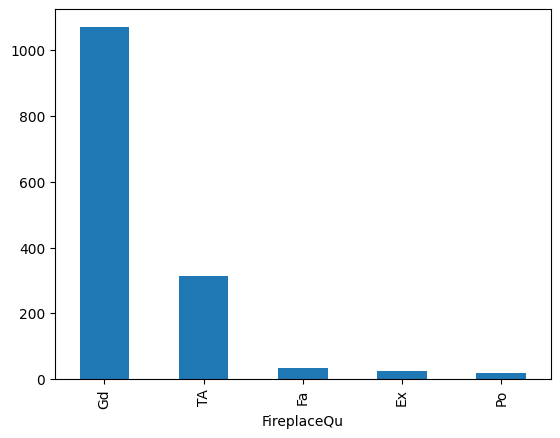

In [79]:
df['FireplaceQu'].value_counts().plot(kind='bar')
plt.show()

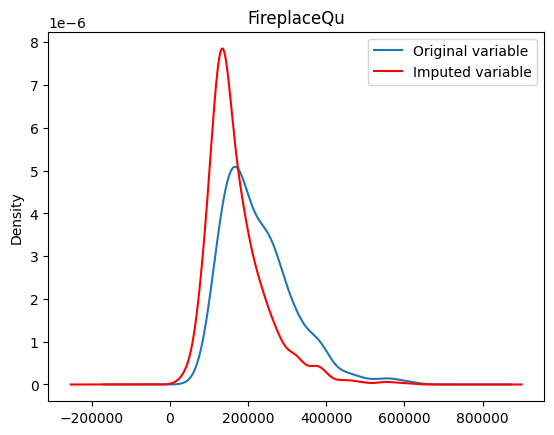

In [80]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde', ax=ax)

# distribution of the variable after imputation
df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde', ax=ax, color='red')

lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# add title
plt.title('FireplaceQu')
plt.show()

In [81]:
# fill using the arbitory value

X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [82]:
imputer = SimpleImputer(strategy='constant',fill_value='Missing')

In [83]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

C:\Users\PRASHANT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(


In [84]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)